In [1]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import torch
from src.data_processing.utils import set_seed
import pandas as pd

from src.models.TimeGAN_torch.timegan_pytorch import TimeGAN
from src.models.TimeGAN_torch.metrics.discriminative_metrics import discriminative_score_metrics
from src.models.TimeGAN_torch.metrics.predictive_metrics import predictive_score_metrics
from src.models.TimeGAN_torch.metrics.visualization_metrics import visualization

from src.data_processing.utils import TimeSeriesDataset

%load_ext autoreload
%autoreload 2

In [2]:
set_seed(42)

Random seed set to: 42


In [3]:
## Newtork parameters
parameters = dict()

parameters['module'] = 'gru'
parameters['hidden_dim'] = 8
parameters['num_layers'] = 2
parameters['batch_size'] = 32
parameters['seq_len'] = 5
parameters['lr'] = 2e-4
parameters['device'] = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
data_set = 'yahoo'

data_path = './data/real_data/yahoo_stock.csv'
scaler_path= f'./model_checkpoints/scalers/scaler_{data_set}.pkl'

# Load and preprocess the data
all_data = pd.read_csv(data_path)
all_data.drop(['Date'], axis=1, inplace=True)

parameters['n_seq'] = all_data.shape[1]

# Create dataset object
dataset = TimeSeriesDataset(data=all_data, seq_len=parameters['seq_len'], n_seq=parameters['n_seq'], scaler_path=scaler_path)

# Get train, val, test datasets
train_dataset, val_dataset, test_dataset = dataset.get_datasets()

# Create DataLoaders (optional)
#train_loader = DataLoader(train_dataset, batch_size=batch_size)
#val_loader = DataLoader(val_dataset, batch_size=batch_size)
#test_loader = DataLoader(test_dataset, batch_size=batch_size)

Initializing TimeSeriesDataset...
Data split: 1460 train, 182 validation, 183 test
1460
18255/1460]
1837/182]
Scaler saved at ./model_checkpoints/scalers/scaler_yahoo.pkl


## Run TimeGAN for synthetic time-series data generation

TimeGAN uses the original data and network parameters to return the generated synthetic data.

In [ ]:
# Run TimeGAN
model = TimeGAN(parameters)

In [ ]:
epochs = 50


model.train(train_dataset, ae_iters=epochs, sup_iters=epochs, joint_iters=epochs)

In [13]:
num_synthetic_samples = len(train_dataset)
synthetic_data = model.generate(num_samples=num_synthetic_samples)
print("synthetic_data shape:", synthetic_data.shape)
# => [100, seq_len, n_seq]

synthetic_data shape: (3680, 5, 6)


## Evaluate the generated data

### 1. Discriminative score

To evaluate the classification accuracy between original and synthetic data using post-hoc RNN network. The output is |classification accuracy - 0.5|.

- metric_iteration: the number of iterations for metric computation.

In [24]:
metric_iteration = 5

discriminative_score = list()
for _ in range(metric_iteration):
  temp_disc = discriminative_score_metrics(ori_data, synthetic_data, iterations=250)
  discriminative_score.append(temp_disc)

print('Discriminative score: ' + str(np.round(np.mean(discriminative_score), 4)))

KeyboardInterrupt: 

## Evaluate the generated data

### 2. Predictive score

To evaluate the prediction performance on train on synthetic, test on real setting. More specifically, we use Post-hoc RNN architecture to predict one-step ahead and report the performance in terms of MAE.

In [ ]:
predictive_score = list()
for tt in range(metric_iteration):
  temp_pred = predictive_score_metrics(ori_data, synthetic_data, iterations=250)
  predictive_score.append(temp_pred)

print('Predictive score: ' + str(np.round(np.mean(predictive_score), 4)))

## Evaluate the generated data

### 3. Visualization

We visualize the original and synthetic data distributions using PCA and tSNE analysis.

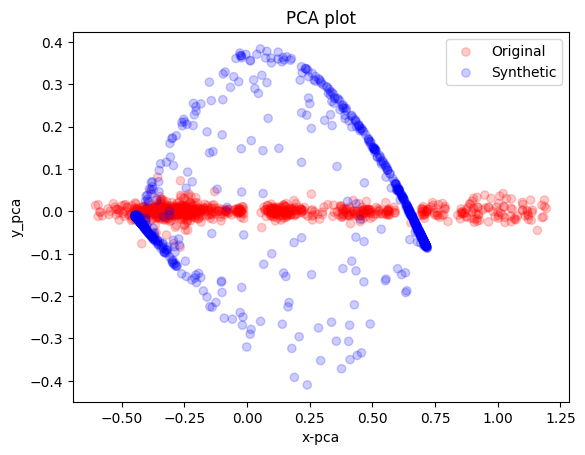

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 2000 samples in 0.002s...
[t-SNE] Computed neighbors for 2000 samples in 0.052s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2000
[t-SNE] Computed conditional probabilities for sample 2000 / 2000
[t-SNE] Mean sigma: 0.001681
[t-SNE] KL divergence after 250 iterations with early exaggeration: 52.161369
[t-SNE] KL divergence after 300 iterations: 0.864441


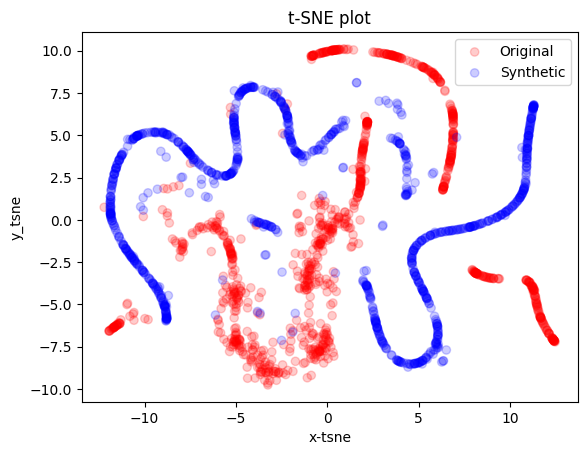

In [25]:
visualization(np.array(ori_data), np.array(synthetic_data), 'pca')
visualization(np.array(ori_data), np.array(synthetic_data), 'tsne')